In [23]:
# 라이브러리 불러오기

import os
from glob import glob

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch

#한글
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 시드 고정 
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# device 설정하기
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("torch :", torch.__version__)
print("device :", device)




torch : 2.11.0+cu128
device : cuda


In [24]:
# 경로 안 폴더 개수 
ROOT = "./archive/kaggle_3m/"

patient_dirs = sorted(glob(ROOT + "TCGA_*"))

print("ROOT :", ROOT)
print("환자 폴더 수 :", len(patient_dirs))



ROOT : ./archive/kaggle_3m/
환자 폴더 수 : 110


In [25]:
# 샘플환자 폴더 이름
sample_dir = patient_dirs[0]
print("샘플 환자폴더:", sample_dir)
print()

# 안에 파일목록
files = sorted(glob(sample_dir + "/*"))
print("폴더안 파일개수:", len(files))
print()

#원본 / 마스크 분류해서 세어보기
imgs = [f for f in files if not f.endswith("_mask.tif")] # 전체 뇌원본
masks = [f for f in files if f.endswith("_mask.tif")] #종양위치 마스킹
print()
print("원본 :", len(imgs), "장")
print("마스크 :", len(masks), "장")

샘플 환자폴더: ./archive/kaggle_3m\TCGA_CS_4941_19960909

폴더안 파일개수: 46


원본 : 23 장
마스크 : 23 장


# 전체 파일 목록으로 표 만들기

In [26]:
# ============================================================
# 셀 4. 전체 파일 목록을 데이터프레임으로
# ============================================================
records = []

for mask_path in glob(ROOT + '*/*_mask.tif'):
    # 마스크 이름에서 '_mask'만 떼면 원본 경로
    img_path = mask_path.replace('_mask.tif', '.tif')

    # 폴더 이름 = 환자 ID
    patient = os.path.basename(os.path.dirname(mask_path))

    # 파일명 끝의 숫자 = 슬라이스 번호
    slice_no = int(os.path.basename(img_path).split('_')[-1].replace('.tif', ''))

    records.append({
        'patient': patient,
        'slice'  : slice_no,
        'image'  : img_path,
        'mask'   : mask_path,
    })

df = pd.DataFrame(records)
df = df.sort_values(['patient', 'slice']).reset_index(drop=True)
# 환자별로 묶고 그안에서 슬라이스 번호순으로 정렬함.

print("표 크기:", df.shape)
print("환자 수:", df['patient'].nunique())
print()
print(df.head(10))

# 슬라이스가 3929장임


표 크기: (3929, 4)
환자 수: 110

                 patient  slice  \
0  TCGA_CS_4941_19960909      1   
1  TCGA_CS_4941_19960909      2   
2  TCGA_CS_4941_19960909      3   
3  TCGA_CS_4941_19960909      4   
4  TCGA_CS_4941_19960909      5   
5  TCGA_CS_4941_19960909      6   
6  TCGA_CS_4941_19960909      7   
7  TCGA_CS_4941_19960909      8   
8  TCGA_CS_4941_19960909      9   
9  TCGA_CS_4941_19960909     10   

                                               image  \
0  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
1  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
2  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
3  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
4  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
5  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
6  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
7  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
8  ./archive/kaggle_3m\TCGA_CS_4941_19960909\TCGA...   
9  ./archive/kaggle_3m\TCGA

In [27]:
# 파일이 다 있는지 확인하기

EXPECT_PATIENTS = 110
EXPECT_SLICES = 3929

# 마스크는 있는데 원본이 없는경우가 있는지 확인
missing = (~df["image"].apply(os.path.exists)).sum()
print("환자 수 :", df["patient"].nunique(), f"(예상 {EXPECT_PATIENTS})")
print("슬라이스 수 :", len(df), f"(예상 {EXPECT_SLICES})")
print("원본 누락 :", missing, "(예상 0)")

#환자별 슬라이스 수
per_patient = df.groupby("patient").size()
print()
print("환자당 슬라이스 수")
print(f" 최소 {per_patient.min()} / 중앙값 {int(per_patient.median())}")
print(f" 최대 {per_patient.max()} / 평균 {int(per_patient.mean())}")

# 문제가 있으면 여기서 멈춘다
problems = []
if df['patient'].nunique() != EXPECT_PATIENTS:
    problems.append(f"환자 {df['patient'].nunique()}명 (기대 {EXPECT_PATIENTS})")
if len(df) != EXPECT_SLICES:
    problems.append(f"슬라이스 {len(df)}장 (기대 {EXPECT_SLICES})")
if missing > 0:
    problems.append(f"원본 누락 {missing}건")

if problems:
    raise ValueError("무결성 검증 실패:\n  - " + "\n  - ".join(problems))

print()
print("[검증 통과]")

# 1명당 평균 35장으 가지고 있음 / 슬라이스를 섞어서 나누면 모든 환자가 train, test 양쪽에 걸림
# 이부분 다시 클로드 돌려서 해석해보기

환자 수 : 110 (예상 110)
슬라이스 수 : 3929 (예상 3929)
원본 누락 : 0 (예상 0)

환자당 슬라이스 수
 최소 20 / 중앙값 33
 최대 88 / 평균 35

[검증 통과]


# 종양 유무 카운트

In [ ]:
# ============================================================
# 셀 6. 마스크를 열어서 종양이 있는지 확인
# ============================================================
def tumor_stats(mask_path):
    """마스크를 읽어 종양 유무와 픽셀 수를 반환"""
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return pd.Series({
        'tumor'   : int(m.max() > 0),      # 흰 픽셀이 하나라도 있으면 1
        'tumor_px': int((m > 0).sum()),    # 흰 픽셀 개수
    })

# 3,929개 마스크를 전부 읽는다 (약 10초)
df = df.join(df['mask'].apply(tumor_stats))

print(df[['patient', 'slice', 'tumor', 'tumor_px']].head(10))
print()
print("컬럼:", list(df.columns))

# 환자 뇌 위쪽 슬라이스라서 tumor 가 0임. (head)

                 patient  slice  tumor  tumor_px
0  TCGA_CS_4941_19960909      1      0         0
1  TCGA_CS_4941_19960909      2      0         0
2  TCGA_CS_4941_19960909      3      0         0
3  TCGA_CS_4941_19960909      4      0         0
4  TCGA_CS_4941_19960909      5      0         0
5  TCGA_CS_4941_19960909      6      0         0
6  TCGA_CS_4941_19960909      7      0         0
7  TCGA_CS_4941_19960909      8      0         0
8  TCGA_CS_4941_19960909      9      0         0
9  TCGA_CS_4941_19960909     10      0         0

컬럼: ['patient', 'slice', 'image', 'mask', 'tumor', 'tumor_px']


In [30]:
IMAGE_SIZE = 256

In [ ]:
# ============================================================
# 셀 7. 클래스 불균형 확인 (분류와 분할문제의 차이떄문 슬라이스단위 + 픽셀 단위 두개라서)
# ============================================================
print("[슬라이스 단위] 종양이 있는 슬라이스 비율")
print(df['tumor'].value_counts())
print()
print(df['tumor'].value_counts(normalize=True).round(3)) 

print()
print("[픽셀 단위] 전체 픽셀 중 종양 픽셀 비율")
total_px = len(df) * IMAGE_SIZE * IMAGE_SIZE # 전체 픽셀 계산하기
tumor_px = df['tumor_px'].sum() #종양 픽셀 계산
print(f"  전체 픽셀 : {total_px:,}")
print(f"  종양 픽셀 : {tumor_px:,}")
print(f"  비율      : {tumor_px / total_px * 100:.3f} %")

print()
print("[종양 슬라이스만] 한 장에서 종양이 차지하는 비율(%)")
pos_ratio = df.loc[df.tumor == 1, 'tumor_px'] / (IMAGE_SIZE * IMAGE_SIZE) * 100
print(pos_ratio.describe().round(2)) 

# 전체 픽셀의 1%만 종양임
# 가장 작은 종양이 전체의 0.01% (min값) 
# 이미지 크기 줄이면 안되는 이유 -> 가장 작은 종양의 크기가 전체의 0.01%라서 리사이즈하면 아예 사라짐
# tumor 에서 0은 빈슬라이스를 말함(전부 검정색) -> 65% 비중임. -> 이걸 학습에 넣으면 전부 배경 그리고 다뺴면 추론에서 정상슬라이스에 종양을 그림
# 그래서 에폭마다 뽑아서 섞는방식 채택 

# 픽셀단위위주로봄

# 정리
# 1.03%      -> 정확도를 쓸수 없음 dice 써야함.
# 65.1%      -> 빈 슬라이스 비율이며 재샘플링이 필요함.
# 7픽셀      -> 가장 작은 종양 (7 픽셀) -> 이미지 256 유지해야함. (65,536 x 0.0001 = 7픽셀)
 


[슬라이스 단위] 종양이 있는 슬라이스 비율
tumor
0    2556
1    1373
Name: count, dtype: int64

tumor
0    0.651
1    0.349
Name: proportion, dtype: float64

[픽셀 단위] 전체 픽셀 중 종양 픽셀 비율
  전체 픽셀 : 257,490,944
  종양 픽셀 : 2,651,854
  비율      : 1.030 %

[종양 슬라이스만] 한 장에서 종양이 차지하는 비율(%)
count    1373.00
mean        2.95
std         2.33
min         0.01
25%         1.12
50%         2.33
75%         4.22
max        12.10
Name: tumor_px, dtype: float64


# 환자 id에서 촬영 기관 코드 추출하기

In [ ]:
parts = df['patient'].str.split('_')

# 형식이 일정한지 먼저 확인 : 3929개(슬라이스 단위 / 환자수 110명)가 전부 4조각
print("조각 수 분포:", parts.str.len().value_counts().to_dict())


df['inst'] = parts.str[1]

print()
print("기관 코드 종류:", sorted(df['inst'].unique()))
print()
print(df[['patient', 'inst']].drop_duplicates().head(5))

# 병원마다 MRI 기계설정이 다르고 촬영밝기등 다달라서
# 어느병원 사진을 가지고와도 다 쓸수있게 하기위해서
# 그리고 그것을 토대ㅗㄹ 고르게 섞어야 평가가 다될수있음.

조각 수 분포: {4: 3929}

기관 코드 종류: ['CS', 'DU', 'EZ', 'FG', 'HT']

                  patient inst
0   TCGA_CS_4941_19960909   CS
23  TCGA_CS_4942_19970222   CS
43  TCGA_CS_4943_20000902   CS
63  TCGA_CS_4944_20010208   CS
83  TCGA_CS_5393_19990606   CS


In [ ]:
# ============================================================
# 셀 9. 기관별 특성 — 정말 기관 차이가 있는지 확인
# ============================================================
# 기관별 환자 수, 슬라이스 수, 종양 비율
g = df.groupby('inst').agg(
    환자수   = ('patient', 'nunique'),
    슬라이스 = ('patient', 'size'),
    종양비율 = ('tumor', 'mean'),
).sort_values('환자수', ascending=False)

# 기관별 FLAIR 밝기 (환자당 3장씩 표본)
rows = []
for inst, sub in df.groupby('inst'):
    vals = []
    for p in sub.groupby('patient').head(3)['image']:
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)[:, :, ::-1]   # BGR -> 원래 순서
        flair = img[:, :, 1] / 255.0                            # 채널 1 = FLAIR
        brain = flair > 0.05                                    # 뇌 영역만 (배경 제외)
        if brain.sum() > 0:
            vals.append(flair[brain].mean())
    rows.append({'inst': inst,
                 'FLAIR평균밝기': np.mean(vals),
                 '표본수': len(vals)})

bright = pd.DataFrame(rows).set_index('inst')

print(g.join(bright).round(4))
print()
print("환자당 슬라이스 수")
print(df.groupby(['inst', 'patient']).size().groupby('inst').mean().round(1))

# inst가 병원인지 뭔지 모름
# 같은 코드끼리 사진이 비슷한지 확인 
# brain = flair > 0.05 /  0.05는 이보다 밝으면 뇌조직이라는 기준선을 의미

#정리
# 1. 밝기가 다름 0.19 / 0.24 (같은뇌를 찍었는데 다르다 = 장비와 설정이 다름 -> 코드가 기관이라는 증거)
# 2. 환자당 슬라이스 수 다름.
# 3. EZ는 환자가 1명뿐. (데이터 나눌떄 고민해봐야함.)


      환자수  슬라이스    종양비율  FLAIR평균밝기  표본수
inst                                   
DU     45  1878  0.3323     0.1905  131
HT     34  1029  0.3926     0.2363   94
CS     16   358  0.3380     0.2445   42
FG     14   640  0.3406     0.2396   41
EZ      1    24  0.2500     0.2506    3

환자당 슬라이스 수
inst
CS    22.4
DU    41.7
EZ    24.0
FG    45.7
HT    30.3
dtype: float64


# 사진 눈으로 확인하여 일치하는지 확인단계

행 1: TCGA_CS_4941_19960909  슬라이스 11  종양 1426px
행 2: TCGA_CS_4941_19960909  슬라이스 12  종양 2646px
행 3: TCGA_CS_4941_19960909  슬라이스 13  종양 2765px


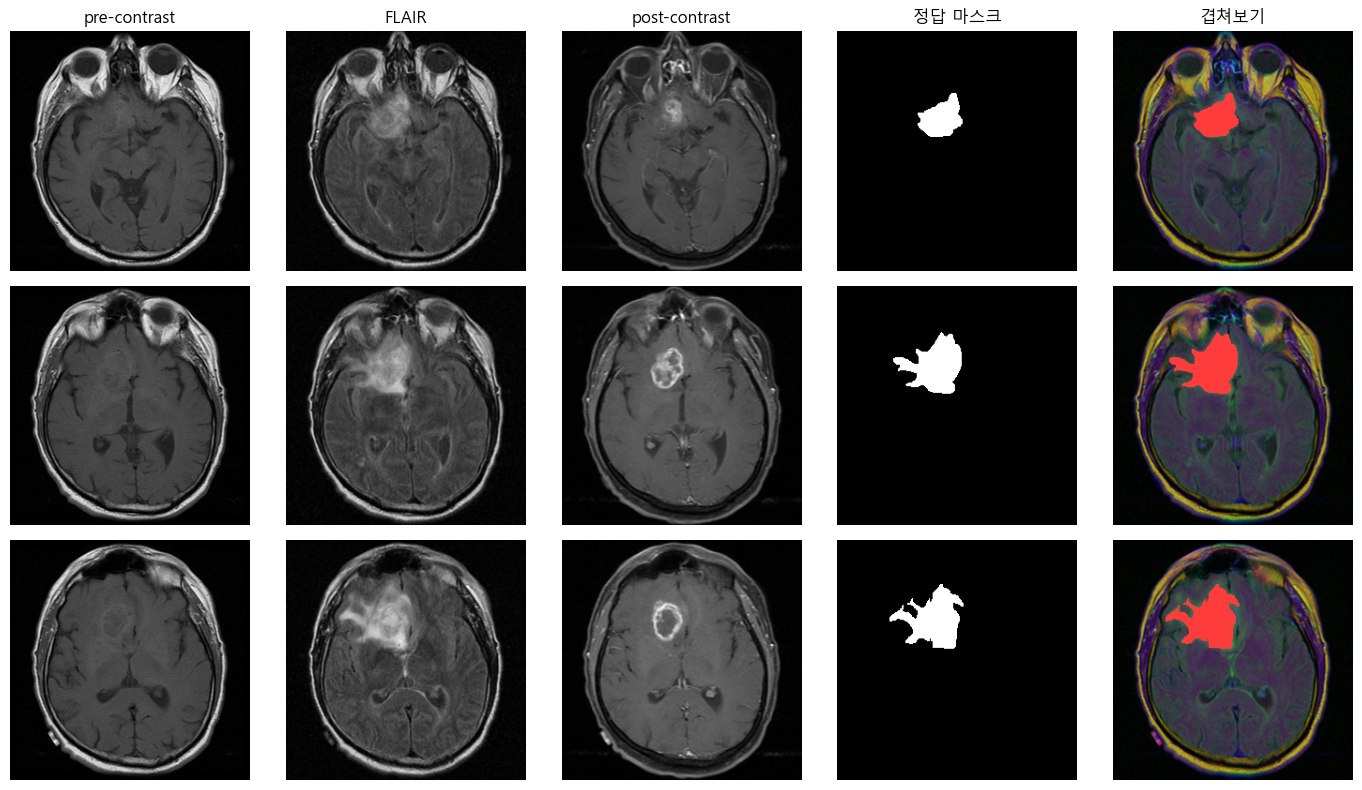

In [ ]:
# ============================================================
# 셀 10. 사진과 마스크를 눈으로 확인
# ============================================================
# 종양이 있는 슬라이스 3장 고르기
idx = df.index[df.tumor == 1][:3]

plt.figure(figsize=(14, 8))
for r, i in enumerate(idx):
    img = cv2.imread(df.loc[i, 'image'], cv2.IMREAD_UNCHANGED)[:, :, ::-1]
    msk = cv2.imread(df.loc[i, 'mask'], cv2.IMREAD_GRAYSCALE)

    # 원본 위에 마스크를 빨갛게 덧칠
    overlay = img.copy()
    overlay[msk > 0] = [255, 60, 60]

    panels = [
        (img[:, :, 0], 'pre-contrast'),
        (img[:, :, 1], 'FLAIR'),
        (img[:, :, 2], 'post-contrast'),
        (msk,          '정답 마스크'),
        (overlay,      '겹쳐보기'),
    ]
    for c, (arr, title) in enumerate(panels):
        plt.subplot(3, 5, r * 5 + c + 1)
        plt.imshow(arr, cmap='gray' if arr.ndim == 2 else None)
        plt.axis('off')
        if r == 0:
            plt.title(title)
    print(f"행 {r+1}: {df.loc[i,'patient']}  슬라이스 {df.loc[i,'slice']}  "
          f"종양 {df.loc[i,'tumor_px']}px")

plt.tight_layout()
plt.show()

# 확인사항 
# 1. 원본과 마스크 짝이 맞는지? -> 종양 위치가 겹치는지?
# 2. 3체널이 정말 다른 사진인지? -> RGB가 아니라는 증거 / 3개가 다 밝기분포와 사진이 다름.
# 3. 마스크가 흰색 + 검정색 맞는가? -> 0/255 확인

# 환자단위 분할하기
## 1번순서 : 잘못된 방법부터

In [ ]:
# ============================================================
# 셀 11-A. 먼저 "잘못된 방법"을 해본다
# ============================================================
# 4번 노트북 방식: 슬라이스를 통째로 섞어서 나눈다
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(df), generator=g).tolist()

n_test = int(len(df) * 0.15)
bad_test  = df.iloc[perm[:n_test]]
bad_train = df.iloc[perm[n_test:]]

overlap = set(bad_train['patient']) & set(bad_test['patient'])

print("[슬라이스 단위로 나눴을 때]")
print(f"  train 슬라이스: {len(bad_train)}")
print(f"  test  슬라이스: {len(bad_test)}")
print(f"  test 환자 수  : {bad_test['patient'].nunique()}명")
print(f"  그중 train에도 있는 환자: {len(overlap)}명")
print()
print(f"  -> test 환자의 {len(overlap)/bad_test['patient'].nunique()*100:.0f}% 가 "
      f"train에도 존재한다")

# test에서 589장 슬라이스를 떼어냈으나, 109명에게서 조금씩 뽑힘.
# 109명은 나머지 슬라이스가 train에 남아있음.
# -> 모델이 학스베서 본 환자를 시험에서 또 본다는 의미.

[슬라이스 단위로 나눴을 때]
  train 슬라이스: 3340
  test  슬라이스: 589
  test 환자 수  : 109명
  그중 train에도 있는 환자: 109명

  -> test 환자의 100% 가 train에도 존재한다


## 2번순서 : 제대로 나누기 (환자단위 + 기관 층화 분할)

In [ ]:
# ============================================================
# 셀 11-B. 환자 단위 + 기관 층화 분할
# ============================================================
def split_by_patient(df, seed=SEED, test_ratio=0.15, val_ratio=0.15):
    rng = np.random.default_rng(seed)

    # 1) 환자 목록 만들기 (110행)
    pdf = df.drop_duplicates('patient')[['patient', 'inst']].copy()

    # 2) 환자별 종양 비율 -> 상/하 2등분
    pdf['ratio'] = pdf['patient'].map(df.groupby('patient')['tumor'].mean())
    pdf['bin']   = pd.qcut(pdf['ratio'], q=2, labels=False, duplicates='drop')

    # 3) 층 = 기관 x 종양비율   (예: 'DU_0', 'DU_1', 'CS_0', ...)
    pdf['strata'] = pdf['inst'] + '_' + pdf['bin'].astype(str)

    # 4) 층마다 따로 섞어서 15% / 15% / 70% 로 배분
    assign = {}
    for st, sub in pdf.groupby('strata'):
        ids = sub['patient'].to_numpy()
        rng.shuffle(ids)
        n = len(ids)

        if n < 3:                                  # 층이 너무 작으면 나눌 수 없다(EZ 기관)
            for p in ids:
                assign[p] = 'train'
            print(f"  [주의] 층 '{st}'는 환자 {n}명뿐 -> train에 고정")
            continue

        n_te = int(round(n * test_ratio))
        n_va = int(round(n * val_ratio))
        for p in ids[:n_te]:            assign[p] = 'test'
        for p in ids[n_te:n_te + n_va]: assign[p] = 'val'
        for p in ids[n_te + n_va:]:     assign[p] = 'train'

    # 5) 환자 배정을 슬라이스에 전파
    return df['patient'].map(assign)


df['split'] = split_by_patient(df)

print()
print(df.groupby('split').agg(
    환자수   = ('patient', 'nunique'),
    슬라이스 = ('patient', 'size'),
    종양비율 = ('tumor', 'mean'),
).reindex(['train', 'val', 'test']).round(3))

# 한환자의 모든 슬라이스를 통쨰로 같은 곳으로 보냄
# 110명을 기준으로 train / val / test를 나눔.

# 사람마다 종양 슬라이스 비율이 달라 2등분 함.
# ex) a: 35장중 5장 종양  / 35장중 20장 종양

# EZ 기관은 표본이 1명이라 일반화 평가에서 제외함. (학습에만쓰고 평가에는 안씀)
# 층이 잘게 쪼개지면 나눌수 없게됨 -> 층당 최소 3명은 잇어야 나눌수 있음.

  [주의] 층 'EZ_0'는 환자 1명뿐 -> train에 고정

       환자수  슬라이스   종양비율
split                  
train   78  2742  0.345
val     16   565  0.375
test    16   622  0.344


# 데이터 누수검사

In [ ]:
# ============================================================
# 셀 12. 데이터 누수 검사
# ============================================================
sets = {k: set(df.loc[df.split == k, 'patient']) for k in ['train', 'val', 'test']}
# SET을 써서 중복없이 집합 후 교집합 바로 구하기

tv = sets['train'] & sets['val']
tt = sets['train'] & sets['test']
vt = sets['val']   & sets['test']

print("환자 교집합 (전부 0이어야 정상)")
print(f"  train ∩ val  : {len(tv)}")
print(f"  train ∩ test : {len(tt)}")
print(f"  val   ∩ test : {len(vt)}")

leak = len(tv) + len(tt) + len(vt)
assert leak == 0, f"데이터 누수 발생! 겹치는 환자 {leak}명"

# 빠진 환자가 없는지도 확인
total = len(sets['train']) + len(sets['val']) + len(sets['test'])
print(f"\n환자 합계: {total} (전체 {df['patient'].nunique()})")
assert total == df['patient'].nunique(), "배정 안 된 환자가 있습니다"

print("\n[누수 없음]")

# 기관이 세 세트에 어떻게 퍼졌나
print()
print("기관 x split (환자 수)")
pat_df = df.drop_duplicates('patient')
print(pd.crosstab(pat_df['inst'], pat_df['split']))


# 교집합 3개가 전부 0 임.
# 기관 4개가 TEST에 들어감. EZ = 0

환자 교집합 (전부 0이어야 정상)
  train ∩ val  : 0
  train ∩ test : 0
  val   ∩ test : 0

환자 합계: 110 (전체 110)

[누수 없음]

기관 x split (환자 수)
split  test  train  val
inst                   
CS        2     12    2
DU        7     31    7
EZ        0      1    0
FG        2     10    2
HT        5     24    5


# 층화 사후 검증
## 층화한건 기관, 종양비율이므로 나머지는 확인이 필요.

In [ ]:
# ============================================================
# 셀 13. 층화하지 않은 변수가 우연히 균형 잡혔는지 확인
# ============================================================
pos = df[df.tumor == 1]      # 종양 있는 슬라이스만

# 환자당 슬라이스 평균 (pandas 버전 무관 방식)
slices_per_patient = df.groupby(['split', 'patient']).size().groupby(level=0).mean()

chk = pd.DataFrame({
    '종양크기 중앙값(px)': pos.groupby('split')['tumor_px'].median(),
    '종양크기 평균(px)'  : pos.groupby('split')['tumor_px'].mean(),
    '최소 종양(px)'      : pos.groupby('split')['tumor_px'].min(),
    '75% 분위(px)'      : pos.groupby('split')['tumor_px'].quantile(0.75),
    '환자당 슬라이스'    : slices_per_patient,
}).reindex(['train', 'val', 'test']).round(1)

print("[층화 기준] 기관 x 종양비율 2분위")
print("[아래는 층화하지 않은 변수 — 우연히 맞았는지 확인]")
print(chk)

# 다른 특성도 많음 - 종양크기, 환자당 슬라이스수, 환자나이, 종양등급 등
# 이것들이 세가지 세트에 고르게 퍼졋는지 아무도 보장안햇음.
# 층당 3명은 있어야 나눌수있어서 층화는 2개로 제한하고 나머지는 사후검증해야함.

[층화 기준] 기관 x 종양비율 2분위
[아래는 층화하지 않은 변수 — 우연히 맞았는지 확인]
       종양크기 중앙값(px)  종양크기 평균(px)  최소 종양(px)  75% 분위(px)  환자당 슬라이스
split                                                            
train        1487.0       1871.9          7      2676.5      35.2
val          1766.0       1910.1         37      2678.2      35.3
test         1600.5       2216.0         23      3481.8      38.9


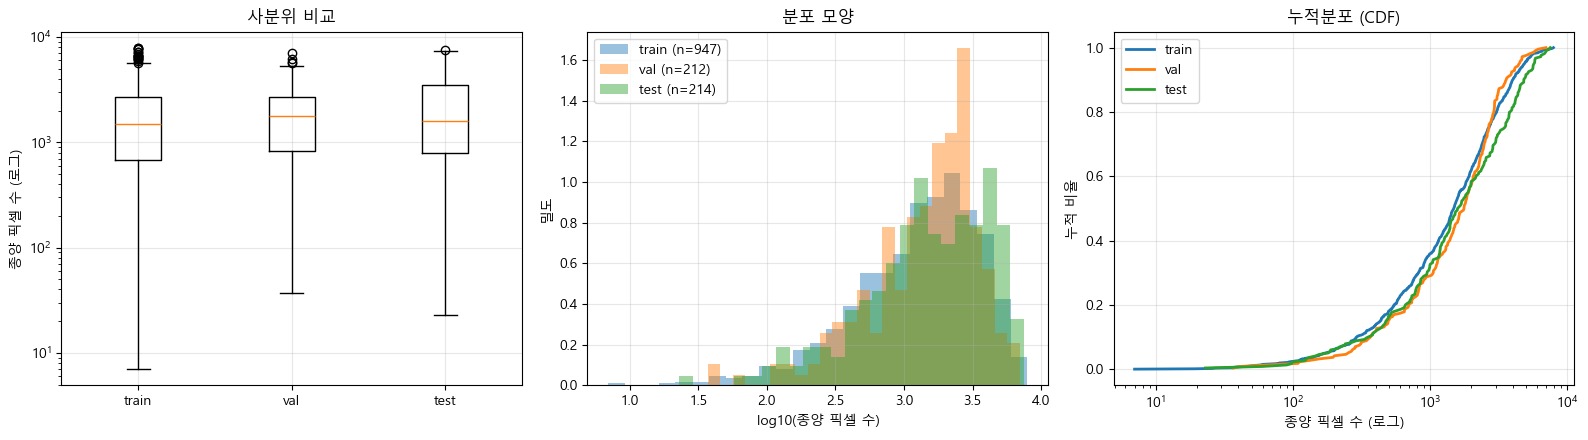

500px 미만 (작은 종양) 비율
  train   18.2 %
  val     15.1 %
  test    16.4 %

3000px 초과 (큰 종양) 비율
  train   20.5 %
  val     16.5 %
  test    29.9 %


In [ ]:
# ============================================================
# 셀 13-B. 종양 크기 분포 비교
# ============================================================
colors = {'train': 'tab:blue', 'val': 'tab:orange', 'test': 'tab:green'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) 박스플롯
axes[0].boxplot([pos.loc[pos.split == sp, 'tumor_px'] for sp in colors],
                tick_labels=list(colors))
axes[0].set_yscale('log')
axes[0].set_ylabel('종양 픽셀 수 (로그)')
axes[0].set_title('사분위 비교')
axes[0].grid(alpha=0.3)

# (2) 히스토그램
for sp, c in colors.items():
    v = pos.loc[pos.split == sp, 'tumor_px']
    axes[1].hist(np.log10(v), bins=25, alpha=0.45, density=True,
                 label=f'{sp} (n={len(v)})', color=c)
axes[1].set_xlabel('log10(종양 픽셀 수)')
axes[1].set_ylabel('밀도')
axes[1].set_title('분포 모양')
axes[1].legend()
axes[1].grid(alpha=0.3)

# (3) 누적분포
for sp, c in colors.items():
    v = np.sort(pos.loc[pos.split == sp, 'tumor_px'].values)
    axes[2].plot(v, np.arange(1, len(v) + 1) / len(v), color=c, lw=2, label=sp)
axes[2].set_xscale('log')
axes[2].set_xlabel('종양 픽셀 수 (로그)')
axes[2].set_ylabel('누적 비율')
axes[2].set_title('누적분포 (CDF)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 보조 지표
print('500px 미만 (작은 종양) 비율')
for sp in colors:
    v = pos.loc[pos.split == sp, 'tumor_px']
    print('  {:6s} {:5.1f} %'.format(sp, 100 * (v < 500).mean()))

print()
print('3000px 초과 (큰 종양) 비율')
for sp in colors:
    v = pos.loc[pos.split == sp, 'tumor_px']
    print('  {:6s} {:5.1f} %'.format(sp, 100 * (v > 3000).mean()))

# 1, 2, 3 나눠서
# 3번은 다겹침 = 분포가 같음 BUT 초록색곡선이 오른쪽으로 더밀려있음 = TEST에 큰종양이 좀더많음.
# 1번은 박스는 다 같은높이이나 수염끝쪽 왼쪽에 수염끝 최저짐이 바닥 = train에 극단적으로 작은종양있음.-> 학습측면에서는 좋음.
# 히스토그램 : val만 유독 높음 표본이 212개라서 생긴 우연.

# 정규화하기

In [ ]:
# ============================================================
# 셀 14. train에서 채널별 평균·표준편차 계산
# ============================================================
train_paths = df.loc[df.split == 'train', 'image'].values
print('train 슬라이스:', len(train_paths))

s  = np.zeros(3, dtype=np.float64)   # 합
ss = np.zeros(3, dtype=np.float64)   # 제곱합
n  = 0                                # 픽셀 개수

for p in train_paths:
    img = cv2.imread(p, cv2.IMREAD_UNCHANGED)[:, :, ::-1]
    x = img.astype(np.float64).reshape(-1, 3) / 255.0
    s  += x.sum(axis=0)
    ss += (x ** 2).sum(axis=0)
    n  += len(x)

MEAN = (s / n).astype(np.float32)
STD  = np.sqrt(ss / n - (s / n) ** 2).astype(np.float32)

print()
print('채널 순서: pre-contrast / FLAIR / post-contrast')
print('train mean:', MEAN.round(4))
print('train std :', STD.round(4))
print()
print('참고 ImageNet mean: [0.485 0.456 0.406]')
print('참고 ImageNet std : [0.229 0.224 0.225]')

# 픽셀값을 평균= 0 /  표준편차 = 1 맞추는것. ->학습 불안정해지기떄문
# imagenet 쓰면 안됨 -> 사전학습 모델이 없음 그리고 mri는 뇌 바깥이 전부 검정이라 평균이 낮음.
# train에서만 계산해야함. -> val and test를 포함하면 데이터 누수임.

#  세 채널 값이 비슷함 -> 같은 부위를 다르게 찍은 흑백사진 세장이라서.

train 슬라이스: 2742

채널 순서: pre-contrast / FLAIR / post-contrast
train mean: [0.0858 0.0822 0.0891]
train std : [0.1302 0.1223 0.1301]

참고 ImageNet mean: [0.485 0.456 0.406]
참고 ImageNet std : [0.229 0.224 0.225]


In [44]:
# ============================================================
# 셀 15. 결과 저장
# ============================================================
# 1) 슬라이스 인덱스 표
df.to_csv('index_split.csv', index=False, encoding='utf-8-sig')
print('index_split.csv 저장:', df.shape)
print('  컬럼:', list(df.columns))

# 2) 정규화 통계 + 설정
import json
meta = {
    'ROOT': ROOT,
    'IMAGE_SIZE': IMAGE_SIZE,
    'SEED': SEED,
    'MEAN': MEAN.tolist(),
    'STD': STD.tolist(),
    'n_patients': int(df['patient'].nunique()),
    'n_slices': int(len(df)),
    'split': {sp: {'patients': int(df.loc[df.split == sp, 'patient'].nunique()),
                   'slices': int((df.split == sp).sum())}
              for sp in ['train', 'val', 'test']},
}
with open('preprocess_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print()
print('preprocess_meta.json 저장')
print(json.dumps(meta, ensure_ascii=False, indent=2))

index_split.csv 저장: (3929, 8)
  컬럼: ['patient', 'slice', 'image', 'mask', 'tumor', 'tumor_px', 'inst', 'split']

preprocess_meta.json 저장
{
  "ROOT": "./archive/kaggle_3m/",
  "IMAGE_SIZE": 256,
  "SEED": 42,
  "MEAN": [
    0.08576905727386475,
    0.08215171098709106,
    0.08907429873943329
  ],
  "STD": [
    0.13019555807113647,
    0.1222635954618454,
    0.13005350530147552
  ],
  "n_patients": 110,
  "n_slices": 3929,
  "split": {
    "train": {
      "patients": 78,
      "slices": 2742
    },
    "val": {
      "patients": 16,
      "slices": 565
    },
    "test": {
      "patients": 16,
      "slices": 622
    }
  }
}
